# Oil Sales Exploratory Data Analysis (EDA)

This notebook focuses on exploring and visualizing the oil sales data to understand:
1. Sales trends over time
2. Distribution of sales by city and manufacturer
3. Price analysis
4. Volume analysis
5. Brand performance
6. Correlations between variables

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_theme()

# Read the cleaned dataset
df = pd.read_csv('../data/cleaned_data.csv')

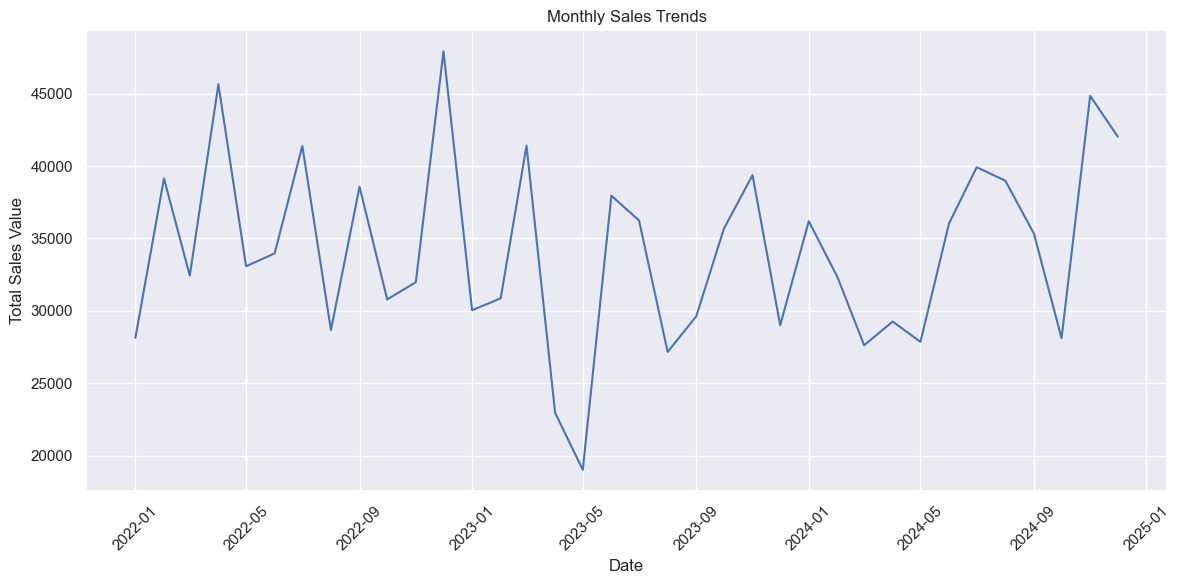

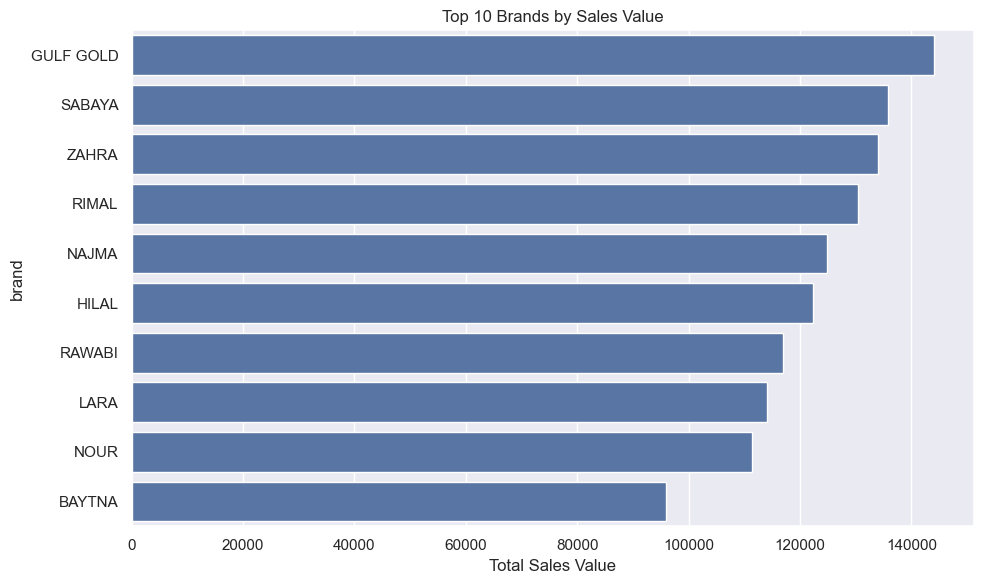

In [3]:
# Sales trends over time
plt.figure(figsize=(12, 6))
monthly_sales = df.groupby(['year', 'month'])['value_sales'].sum().reset_index()
monthly_sales['date'] = pd.to_datetime(monthly_sales[['year', 'month']].assign(day=1))
plt.plot(monthly_sales['date'], monthly_sales['value_sales'])
plt.title('Monthly Sales Trends')
plt.xlabel('Date')
plt.ylabel('Total Sales Value')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Top selling brands
plt.figure(figsize=(10, 6))
top_brands = df.groupby('brand')['value_sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_brands.values, y=top_brands.index)
plt.title('Top 10 Brands by Sales Value')
plt.xlabel('Total Sales Value')
plt.tight_layout()
plt.show()

In [ ]:
# Sales by City
plt.figure(figsize=(10, 6))
city_sales = df.groupby('city')['value_sales'].sum().sort_values(ascending=True)
sns.barplot(x=city_sales.values, y=city_sales.index)
plt.title('Sales by City')
plt.xlabel('Total Sales Value')
plt.tight_layout()
plt.show()

# Correlation Analysis
plt.figure(figsize=(10, 8))
numeric_cols = ['value_sales', 'volume_sales', 'average_price', 'size']
correlation = df[numeric_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()